# Introduction to Value at Risk (VaR) Analysis for GN Stock

Welcome to this section of our notebook, where we delve into the crucial concept of Value at Risk (VaR) to assess the potential financial exposure of our investment in GN stock.

**What is Value at Risk (VaR)?**

Value at Risk is a widely used financial metric that quantifies the maximum potential loss an investment, portfolio, or firm could experience over a specific time horizon, given a certain confidence level. In simpler terms, it answers the question: "What is the most I can expect to lose on this investment with a certain probability over a set period?"

For instance, **a VaR of \\$1 million at a 95% confidence level over one day means that, under normal market conditions, there is a 5% chance (or 1 in 20 days) that the loss will exceed \\$1 million in a single day. Conversely, there is a 95% chance that the loss will be less than $1 million.**



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Let's load the data. For this example I am analyzing Natural Gas

In [3]:
df = pd.read_excel('GN.xlsx')
df.head()

,Date,GAS NATURAL usd$/MMBtu
0,2021-11-02,5.330
1,2021-11-01,5.180
2,2021-10-29,5.412
3,2021-10-28,5.610
4,2021-10-27,5.860


In [4]:
df.columns = ['date','price']

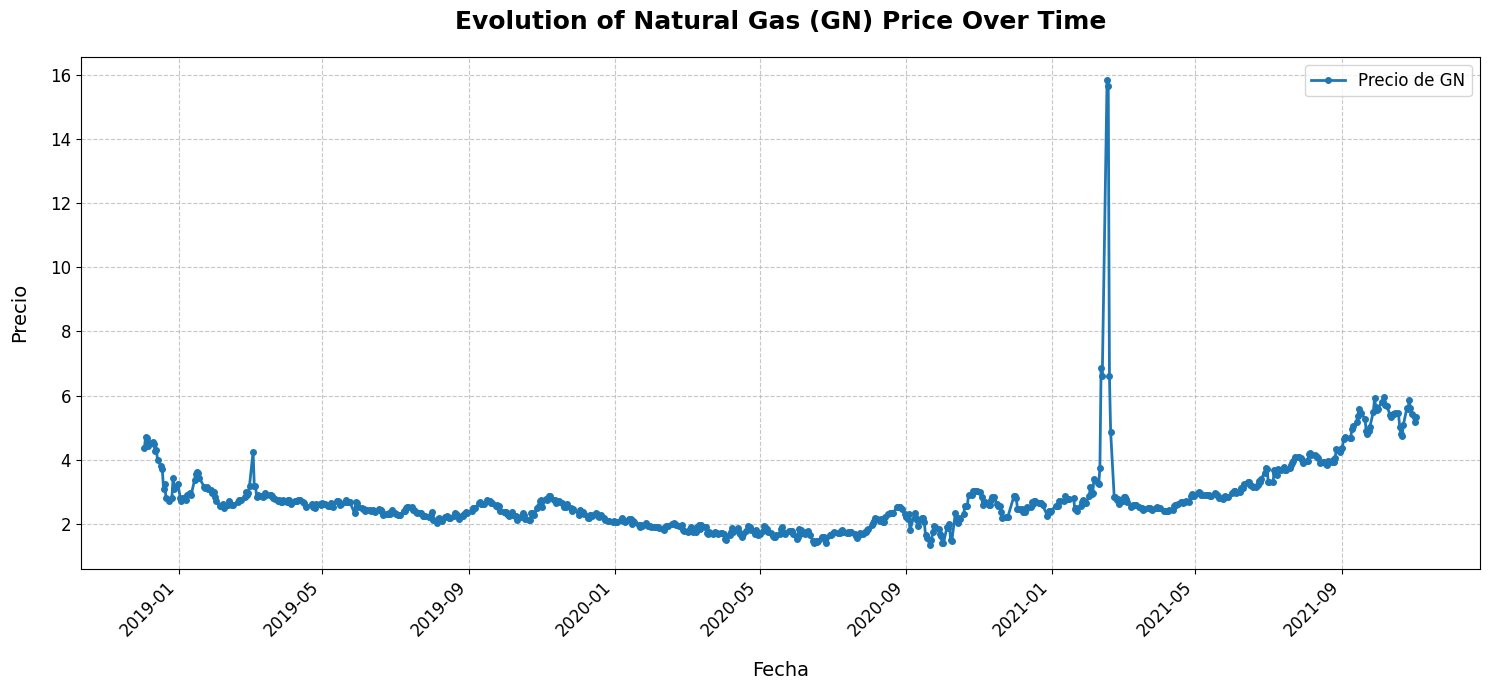

In [7]:
plt.figure(figsize=(15, 7))

plt.plot(df['date'], df['price'], color='#1f77b4', linewidth=2, marker='o', markersize=4, label='Precio de GN')

plt.title('Evolution of natural Gas (GN) price over time', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=14, labelpad=15)
plt.ylabel('Precio', fontsize=14, labelpad=15)


plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

In [8]:
# Calculate the previous day's closing price
df['prev_price'] = df['price'].shift(1)

# Calculate simple daily profit (percentage change)
# Profit = (Current Price - Previous Price) / Previous Price
df['profit'] = ((df['price'] - df['prev_price']) / df['prev_price']).round(3)

# Calculate logarithmic daily profit (log return)
# Log return = ln(Current Price / Previous Price)
# Log returns are often preferred in financial modeling due to their additive property.
df['profit_log'] = np.log(df['price'] / df['prev_price'])

df.dropna(inplace=True)

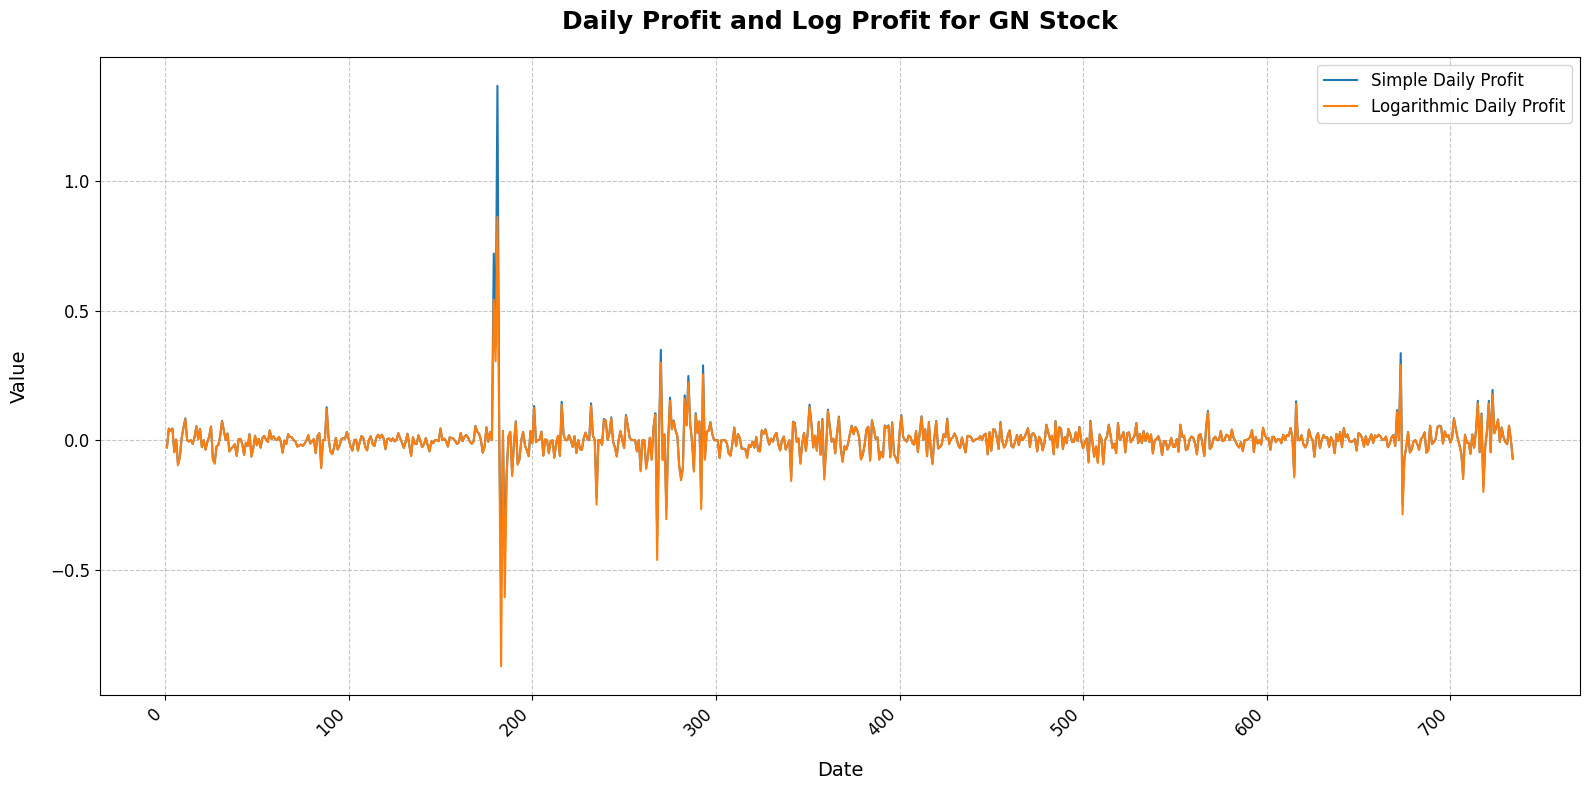

In [10]:
plt.figure(figsize=(16, 8))

# Plot 'profit' and 'profit_log' columns.# df.set_index('date') is used to make 'date' the x-axis for plotting.
df[['profit', 'profit_log']].plot(ax=plt.gca(), linewidth=1.5) # Use ax=plt.gca() to plot on the current figure

plt.title('Daily profit and log profit for GN stock', fontsize=18, fontweight='bold', pad=20)

plt.xlabel('Date', fontsize=14, labelpad=15)
plt.ylabel('Value', fontsize=14, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(['Simple Daily Profit', 'Logarithmic Daily Profit'], fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

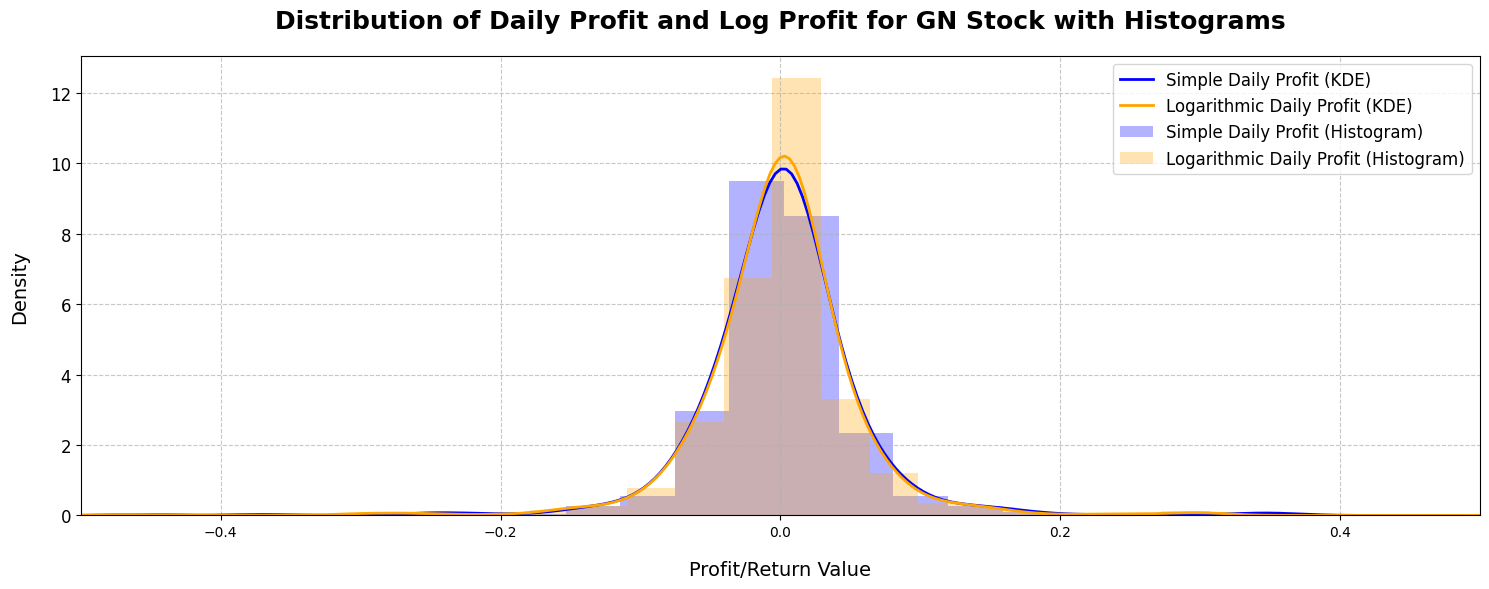

In [17]:
plt.figure(figsize=(15, 6))

ax = df['profit'].plot.kde(linewidth=2, label='Simple Daily Profit (KDE)', color='blue')

df['profit_log'].plot.kde(ax=ax, linewidth=2, label='Logarithmic Daily Profit (KDE)', color='orange')

df['profit'].plot.hist(ax=ax, bins=50, density=True, alpha=0.3, label='Simple Daily Profit (Histogram)', color='blue')
df['profit_log'].plot.hist(ax=ax, bins=50, density=True, alpha=0.3, label='Logarithmic Daily Profit (Histogram)', color='orange')


plt.title('Distribution of Daily Profit and Log Profit for GN Stock with Histograms', fontsize=18, fontweight='bold', pad=20)

plt.xlabel('Profit/Return Value', fontsize=14, labelpad=15)
plt.ylabel('Density', fontsize=14, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(fontsize=12)

plt.yticks(fontsize=12)

plt.xlim(-0.5, 0.5)

plt.tight_layout()

plt.show()

## Calculate the mean (expected) daily profit. 

This gives an average of the historical daily profit values.

In [27]:
mean_profit = df['profit'].mean()

## Calculate the standard deviation of daily profit.

This is a key measure of historical volatility or risk.

In [28]:
std_profit_vol = df['profit'].std()

## Calculate the Coefficient of Variation (CV).
CV = (Standard Deviation) / (Mean). It measures the dispersion of data points around the mean, relative to the mean. A higher CV indicates greater risk
per unit of expected return. 

Added a check to prevent division by zero if profit_e is zero.

In [29]:
if mean_profit != 0:
    cv_value = std_profit_vol / mean_profit
else:
    cv_value = np.nan

## Value at Risk (VaR) Calculation
VaR is used to quantify the maximum potential loss over a specified time horizon
at a given confidence level. Here, we use the Historical Method, taking quantiles.

Calculate VaR at 95% confidence level.
In financial contexts, VaR typically focuses on potential losses.
If 'profit' column contains positive values for gains and negative for losses,
then `quantile(0.05)` would represent the value below which 5% of returns fall (i.e., the worst 5% losses).
The original `quantile(0.95)` would represent the 95th percentile profit (a good profit).
To represent VaR as a potential loss, we should consider a lower quantile.
For a 95% confidence that loss won't exceed X, you look at the 5th percentile (0.05 quantile)
if profit values are positive for gains and negative for losses.
Or, if profit is always positive, and you want the worst 5%, then you'd sort and pick.
Assuming 'profit' can be negative for losses, we interpret VaR as the magnitude of loss.

In [30]:

# Represents the 5th percentile (worst 5% outcome)
var_95_value = df['profit'].quantile(0.05)

# Represents the 1st percentile (worst 1% outcome)
var_99_value = df['profit'].quantile(0.01)


## Descriptive Statistics with Specific Percentiles

In [32]:
# Generate descriptive statistics for the 'profit' column.
profit_description = df['profit'].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])

# Display the calculated metrics and descriptive statistics
print("Profitability and Volatility Metrics:")
print(f"  Expected Daily Profit (profit_e): {mean_profit:.4f}")
print(f"  Standard Deviation of Profit (std_vol): {std_profit_vol:.4f}")
print(f"  Coefficient of Variation (cv): {cv_value:.4f}")
print(f"  VaR_95 (5th percentile loss): {var_95_value:.4f}")
print(f"  VaR_99 (1st percentile loss): {var_99_value:.4f}")
print("\nDescriptive Statistics for Daily Profit (with custom percentiles)")

Profitability and Volatility Metrics:
  Expected Daily Profit (profit_e): 0.0028
  Standard Deviation of Profit (std_vol): 0.0841
  Coefficient of Variation (cv): 30.1646
  VaR_95 (5th percentile loss): -0.0730
  VaR_99 (1st percentile loss): -0.1694

Descriptive Statistics for Daily Profit (with custom percentiles)


## Analysis

Let's break down the key financial metrics you've calculated for GN stock:

1. Expected Daily Profit (profit_e): 0.0028

Interpretation: This value represents the average daily profit (or return) on GN stock over the analyzed period. A positive value of 0.0028 (or 0.28%) indicates that, on average, the stock has generated a small positive return each day. This is the expected return based on historical performance.

2. Standard Deviation of Profit (std_vol): 0.0841

Interpretation: The standard deviation measures the volatility or risk of the daily profits. A value of 0.0841 (or 8.41%) indicates a relatively significant dispersion around the mean profit. In simpler terms, the daily profits (and losses) tend to fluctuate quite a bit from the average. This is your historical measure of the stock's "swinginess."

3. Coefficient of Variation (cv): 30.1646

Interpretation: The Coefficient of Variation is a measure of risk per unit of return. It's calculated as (Standard Deviation / Mean). A very high CV, like 30.16, suggests that the volatility (risk) is extremely high relative to the average daily profit. This is a crucial indicator: while the stock might have a positive expected return, that return comes with a very large amount of variability. An investment with a CV over 1 is generally considered to have high volatility relative to its expected return, and 30.16 is exceptionally high, implying that the average profit is very small compared to the daily fluctuations.

4. VaR_95 (5th percentile loss): -0.0730

Interpretation: This is your Value at Risk at a 95% confidence level. It means that, based on historical data, there is a 5% chance (or 1 day out of 20) that the daily loss on GN stock will be equal to or greater than 7.30% (i.e., -0.0730). Conversely, there's a 95% chance that the daily loss will be less than 7.30%. This quantifies your downside risk under "normal" market conditions.

5. VaR_99 (1st percentile loss): -0.1694

Interpretation: This is your Value at Risk at a 99% confidence level. It implies that there is a 1% chance (or 1 day out of 100) that the daily loss on GN stock will be equal to or greater than 16.94% (i.e., -0.1694). This represents a more extreme, but less probable, worst-case daily loss scenario.

## Overall Summary for GN Stock:

Looking at the historical data for GN stock, my analysis reveals something quite interesting. While it does show a very slight average daily profit, what really stands out is its remarkably high volatility and the significant potential for losses.

When we dive deeper, the price plot clearly highlights a major outlier event around early 2021. During that period, the stock price experienced an unusual and dramatic surge from around $4 to nearly $16, only to quickly fall back to more typical levels. This singular, extreme spike has had a disproportionate effect on our calculated volatility metrics.

To be more precise:

* The Standard Deviation of Profit (std_vol) of 0.0841 (8.41%) appears to be quite inflated by this rare occurrence. In essence, this outlier makes the stock seem far more erratic than it might typically be during periods of more stable market behavior.

* Similarly, the Coefficient of Variation (CV) of 30.16 is exceptionally high, which is a strong indicator of this distortion. It tells us that the level of risk you're taking is enormous when compared to the very modest average daily return. This metric is especially sensitive to those large deviations caused by isolated extreme events.

Consequently, the VaR (Value at Risk) figures also reflect this elevated volatility, giving us a clearer picture of the downside:

* Based on this historical view, you could realistically face a daily loss of at least 7.30% on approximately one out of every twenty trading days (VaR_95).

* In even more extreme (though less frequent) scenarios, there's a 1% chance (about one day in a hundred) that you could see a loss exceeding 16.94% (VaR_99).

It's important for us to recognize that while these metrics accurately capture the historical data, including that **standout outlier**, they might be overstating the "typical" day-to-day risk of GN stock. If that early 2021 spike is truly a one-off anomaly, then the actual, underlying risk might be somewhat less dramatic. For anyone considering investing in GN stock, it's crucial to be prepared for substantial daily price swings. Moving forward, I'd suggest exploring statistical methods to minimize the influence of such outliers. This could help us gain a more robust and truly representative assessment of the stock's fundamental risk under normal market conditions.